<a href="https://colab.research.google.com/github/cursuri-inf/IPAP/blob/main/saptamana-01/curs01_demonstratii.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cursul 1. Demonstrațiile

Caietul conține cele trei demonstrații de la cursul 1, cu rezultatele salvate: ce vede un model preantrenat într-o poză (§4.1), dacă un model poate citi o recenzie în română (§4.2) și dacă o rețea prezice mai bine decât o metodă simplă (§4.3). Titlurile au numerele secțiunilor din suportul de curs.

Nu trebuie să înțelegeți codul. Îl rulați, priviți rezultatul și vă gândiți la întrebarea de la sfârșitul fiecărei demonstrații.

**Cum lucrezi:**

1. Deschizi caietul cu butonul „Open in Colab” de mai sus. Colab avertizează că documentul nu a fost creat de Google: caietul vine din depozitul cursului, așa că alegi „Run anyway”.
2. Înainte să schimbi ceva: File → Save a copy in Drive; lucrezi în copie.
3. Rezultatele salvate se văd și fără rulare. Ca să le obții din nou, rulezi celulele în ordine, de sus în jos, cu Shift+Enter. Prima rulare descarcă modelele (câteva minute).
4. Apoi încerci pe datele tale: pozele tale la D1, frazele tale la D2.
5. Notițele tale: după fiecare demonstrație ai o celulă „Notițele mele” (dublu clic ca s-o editezi). Poți lăsa și comentarii pe marginea din dreapta a oricărei celule: clic dreapta pe celulă, apoi „Add a comment” (sau Ctrl+Alt+M).

Caietul rulează pe procesor; un GPU nu este necesar. Nu se predă și nu se notează.

## 0. Pornire

Versiunile bibliotecilor. În alte versiuni, unele cifre pot diferi la ultima zecimală.

In [1]:
import sys, torch, torchvision, transformers

print("Python      ", sys.version.split()[0])
print("PyTorch     ", torch.__version__)
print("torchvision ", torchvision.__version__)
print("transformers", transformers.__version__)

Python       3.13.13
PyTorch      2.11.0+cpu
torchvision  0.26.0+cpu
transformers 5.19.0


## D1. Ce vede un model preantrenat într-o poză (§4.1)

Modelul este ResNet-50, antrenat pe ImageNet-1k: aproximativ 1,3 milioane de imagini în 1.000 de categorii. Pentru fiecare poză afișează primele trei etichete, cu probabilitatea fiecăreia.

**Pozele tale.** În Colab, celula de mai jos deschide o fereastră de încărcare: alegi 1–4 fotografii (JPG sau PNG; cele HEIC de pe iPhone se convertesc întâi în JPG). Dacă nu alegi nimic sau rulezi caietul în afara Colab, se folosește o poză de exemplu.

In [2]:
import shutil, urllib.request

try:
    from google.colab import files
    pozele = list(files.upload())   # pozele tale
except ImportError:                 # în afara Colab
    pozele = []
if not pozele:   # fără poze: o poză de exemplu
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/pytorch/"
        "hub/master/images/dog.jpg", "exemplu.jpg")
    pozele = ["exemplu.jpg"]
# prima poză devine poza.jpg, ca în suport
shutil.copy(pozele[0], "poza.jpg")
print(pozele)

['exemplu.jpg']


Codul din suport (caseta „Pentru curioși” din §4.1), pe prima poză:

In [3]:
import torch
from PIL import Image
from torchvision.models import resnet50, ResNet50_Weights

# parametrii învățați pe ImageNet
weights = ResNet50_Weights.DEFAULT
# modelul, în modul de folosire
model = resnet50(weights=weights).eval()
# redimensionare și normalizare
preprocess = weights.transforms()

img = Image.open("poza.jpg").convert("RGB")
x = preprocess(img).unsqueeze(0)
with torch.no_grad():  # doar predicție
    prob = model(x).softmax(dim=1)[0]
top = prob.topk(3)  # primele 3 din 1.000
for p, i in zip(top.values, top.indices):
    eticheta = weights.meta["categories"][i]
    print(eticheta, f"{p:.1%}")

Samoyed 43.7%
white wolf 2.1%
Pomeranian 1.3%


Același model, pe toate pozele încărcate, fiecare cu imaginea ei micșorată:

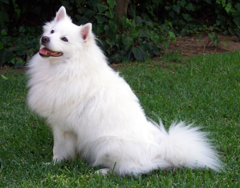

  Samoyed: 43.7%
  white wolf: 2.1%
  Pomeranian: 1.3%


In [4]:
from IPython.display import display

for nume in pozele:
    img = Image.open(nume).convert("RGB")
    img.thumbnail((240, 240))  # micșorată
    display(img)
    img = Image.open(nume).convert("RGB")
    with torch.no_grad():
        prob = model(preprocess(img).unsqueeze(0))
        prob = prob.softmax(dim=1)[0]
    top = prob.topk(3)
    for p, i in zip(top.values, top.indices):
        eticheta = weights.meta["categories"][i]
        print(f"  {eticheta}: {p:.1%}")

**Întrebarea.** Ce a învățat modelul și de unde? Încearcă o poză cu ceva care nu are categorie în ImageNet (o clădire din orașul tău, o mâncare tradițională): ce etichetă ai fi pus tu și de ce nu a putut-o pune modelul?

### Notițele mele

…

## D2. Poate un model să citească o recenzie în română? (§4.2)

Modelul este XLM-R, preantrenat pe text în aproximativ 100 de limbi, printre care româna, apoi adaptat pe recenzii de produse în română, etichetate ca pozitive sau negative (`DGurgurov/xlm-r_romanian_sentiment`, de pe Hugging Face). Mai jos sunt cele patru recenzii din tabelul suportului: două evidente și două capcane.

In [5]:
from transformers import pipeline

clasificator = pipeline(
    "text-classification",
    model="DGurgurov/xlm-r_romanian_sentiment")
ETICHETE = {"LABEL_0": "negativ", "LABEL_1": "pozitiv"}

recenzii = [
    "Livrare rapidă, produsul e exact ca în descriere.",
    "S-a stricat după o zi, nu recomand.",
    "Nu a fost deloc rău.",
    "Minunat, iar a întârziat comanda.",
]
for r, p in zip(recenzii, clasificator(recenzii)):
    et = ETICHETE[p["label"]]
    print(f"{et} {p['score']:4.0%}  {r}")

pozitiv  99%  Livrare rapidă, produsul e exact ca în descriere.
negativ 100%  S-a stricat după o zi, nu recomand.
pozitiv  63%  Nu a fost deloc rău.
negativ  99%  Minunat, iar a întârziat comanda.


### Încercați acum

Scrieți frazele voastre în listă (ironie, negație, text fără diacritice, română amestecată cu engleză) și rulați. Căutați o frază care păcălește modelul.

In [6]:
ale_mele = [
    "Super, doar ca s-a rupt la prima folosire.",
    "Nu e rau deloc, ma asteptam la mai putin.",
    "Recomand, dar livrarea a durat o saptamana.",
]
for r, p in zip(ale_mele, clasificator(ale_mele)):
    et = ETICHETE[p["label"]]
    print(f"{et} {p['score']:4.0%}  {r}")

pozitiv  95%  Super, doar ca s-a rupt la prima folosire.
pozitiv  68%  Nu e rau deloc, ma asteptam la mai putin.
pozitiv  98%  Recomand, dar livrarea a durat o saptamana.


### Pe recenzii adevărate

Același model, pe 100 de recenzii din setul de test LaRoSeDa (50 pozitive, cu 4–5 stele, și 50 negative, cu 1–2 stele); autorul modelului a folosit setul de test doar pentru evaluare, nu la adaptare. Celula afișează acuratețea și primele recenzii greșite.

In [7]:
import json, random

URL = ("https://raw.githubusercontent.com/ancatache/"
       "LaRoSeDa/main/data_splitted/laroseda_test.json")
with urllib.request.urlopen(URL) as f:
    toate = json.load(f)["reviews"]
poz = [r for r in toate if r["starRating"] in "45"]
neg = [r for r in toate if r["starRating"] in "12"]
random.seed(0)
esantion = (random.sample(poz, 50)
            + random.sample(neg, 50))
texte = [r["content"] for r in esantion]
reale = ["pozitiv"] * 50 + ["negativ"] * 50
rez = clasificator(texte, truncation=True)
prezise = [ETICHETE[p["label"]] for p in rez]
perechi = list(zip(texte, reale, prezise))
corecte = sum(a == b for _, a, b in perechi)
print(f"acuratețea: {corecte} din 100")
greseli = [(t, a) for t, a, b in perechi if a != b]
for t, a in greseli[:3]:
    print(f"- de fapt {a}: {t[:80]}")

acuratețea: 96 din 100
- de fapt pozitiv: totul decurge conform descrierii.... de la produs, pana la tine acasa...
- de fapt pozitiv: smecher   o sa il cumpar!!
- de fapt pozitiv: am achizitionat acest produs si sunt foarte nultumit! felicitari emag!!!


**Întrebarea.** Ce au în comun frazele care păcălesc modelul? Ce diferă între ele și recenziile pe care modelul le clasifică bine?

### Notițele mele

…

## D3. Poate o rețea să prezică vânzările lunii viitoare? (§4.3)

Seria din figura 4.1: vânzări lunare simulate, în mii de lei, pe ultimii trei ani încheiați (T = anul curent). Ultimele șase luni, iulie–decembrie T-1, sunt ascunse: nicio metodă nu le vede până la comparație.

**Metoda simplă:** valoarea din aceeași lună a anului trecut, plus creșterea medie de la un an la altul.

In [8]:
import torch

# 36 de luni: ianuarie T-3 ... decembrie T-1
serie = torch.tensor([
    113, 116, 119, 112, 107, 98, 97, 93, 97,
    104, 117, 125, 130, 135, 135, 126, 125, 117,
    114, 109, 113, 120, 133, 141, 149, 150, 149,
    147, 137, 134, 128, 128, 130, 139, 145, 156,
], dtype=torch.float32)
real = serie[30:]  # iulie–decembrie T-1, ascunse
# creșterea medie de la un an la altul, pe lunile știute
crestere = (serie[12:30] - serie[0:18]).mean()
simpla = (serie[18:24] + crestere).round()
print("creșterea medie:", round(crestere.item(), 1))
print("metoda simplă:  ", simpla.int().tolist())
print("real:           ", real.int().tolist())

creșterea medie: 16.6
metoda simplă:   [131, 126, 130, 137, 150, 158]
real:            [128, 128, 130, 139, 145, 156]


**Rețeaua:** un perceptron mic (12 intrări, 16 neuroni ascunși, o ieșire) care primește ultimele 12 luni și prezice luna următoare. Lunile știute dau doar 18 exemple de antrenare. Prognoza se face pas cu pas: fiecare lună prezisă intră în fereastra lunii următoare.

In [9]:
from torch import nn

def antreneaza_si_prezice(samanta):
    torch.manual_seed(samanta)
    m, s = serie[:30].mean(), serie[:30].std()
    z = (serie[:30] - m) / s     # standardizare
    X = torch.stack([z[t - 12:t] for t in range(12, 30)])
    Y = z[12:30].unsqueeze(1)    # 18 exemple
    retea = nn.Sequential(nn.Linear(12, 16), nn.ReLU(),
                          nn.Linear(16, 1))
    opt = torch.optim.Adam(retea.parameters(), lr=0.01)
    for epoca in range(500):
        p = nn.functional.mse_loss(retea(X), Y)
        opt.zero_grad()
        p.backward()
        opt.step()
    istoric = list(z)
    with torch.no_grad():        # 6 luni, pas cu pas
        for luna in range(6):
            x = torch.stack(istoric[-12:]).unsqueeze(0)
            istoric.append(retea(x)[0, 0])
    return (torch.stack(istoric[30:]) * s + m).round()

retea = antreneaza_si_prezice(0)
print("rețeaua:", retea.int().tolist())

rețeaua: [130, 136, 147, 158, 176, 195]


**Comparația:** eroarea absolută medie (MAE), adică media erorilor lunare, în valoare absolută. Are unitatea datelor, mii de lei.

In [10]:
luni = ["iulie", "august", "septembrie", "octombrie",
        "noiembrie", "decembrie"]
print(f"{'luna':11}{'real':>5}{'simplă':>8}{'eroare':>8}"
      f"{'rețeaua':>9}{'eroare':>8}")
for i, l in enumerate(luni):
    r, a, b = real[i], simpla[i], retea[i]
    print(f"{l:11}{r:5.0f}{a:8.0f}{abs(r - a):8.0f}"
          f"{b:9.0f}{abs(r - b):8.0f}")
mae_simpla = (simpla - real).abs().mean().item()
mae_retea = (retea - real).abs().mean().item()
print(f"eroarea medie: metoda simplă {mae_simpla:.1f}, "
      f"rețeaua {mae_retea:.1f}")

luna        real  simplă  eroare  rețeaua  eroare
iulie        128     131       3      130       2
august       128     126       2      136       8
septembrie   130     130       0      147      17
octombrie    139     137       2      158      19
noiembrie    145     150       5      176      31
decembrie    156     158       2      195      39
eroarea medie: metoda simplă 2.3, rețeaua 19.3


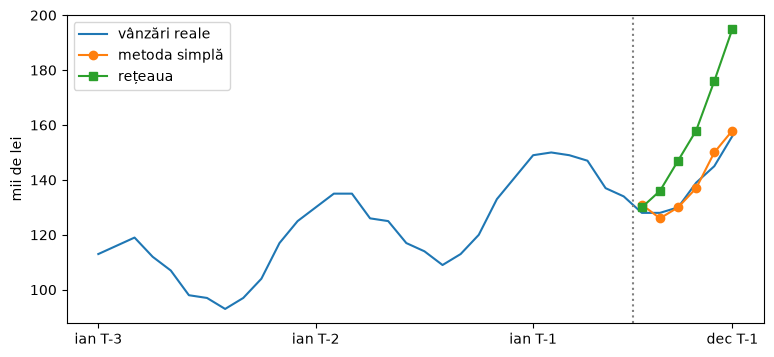

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(range(36), serie, label="vânzări reale")
luni_test = range(30, 36)
plt.plot(luni_test, simpla, "o-", label="metoda simplă")
plt.plot(luni_test, retea, "s-", label="rețeaua")
plt.axvline(29.5, color="gray", linestyle=":")
plt.xticks([0, 12, 24, 35], ["ian T-3", "ian T-2",
                             "ian T-1", "dec T-1"])
plt.ylabel("mii de lei")
plt.legend()
plt.show()

### Încercați acum

Aceeași rețea, pornită de la alți parametri inițiali (altă sămânță). Prevedeți întâi: iese de fiecare dată aceeași eroare?

In [12]:
for samanta in range(5):
    pr = antreneaza_si_prezice(samanta)
    mae = (pr - real).abs().mean().item()
    print(f"sămânța {samanta}: eroarea medie {mae:.1f}")

sămânța 0: eroarea medie 19.3


sămânța 1: eroarea medie 2.8


sămânța 2: eroarea medie 9.7


sămânța 3: eroarea medie 5.7


sămânța 4: eroarea medie 5.0


**Întrebarea.** Ați alege rețeaua dacă, la o altă rulare, ar avea o eroare medie puțin mai mică decât metoda simplă? Ce ați mai vrea să știți înainte să decideți?

### Notițele mele

…

## Mai departe

La laboratorul 2 adaptați un model preantrenat pe imagini (ca la D1, dar cu categoriile voastre); textul în română revine în săptămâna 11, iar seriile de timp în săptămâna 9, cu referința simplă alături de fiecare rețea.